<a href="https://colab.research.google.com/github/olawaleaboderin/machine_learning/blob/main/Assignment4_train_mnist_cnn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Convolutional Neural Network for MNIST data set

**AI Prompt:** *Create a PyTorch script to fine-tune a pre-trained convolutional neural network for the MNIST dataset. The model should use ResNet-18 pre-trained on ImageNet, adapted for grayscale 28×28 images with 10 output classes. Fine-tune for 3 epochs, show training accuracy, and save the model weights as a .pth file.*

## 1 · Install / verify dependencies

In [ ]:
import torch, torchvision
print('PyTorch :', torch.__version__)
print('torchvision:', torchvision.__version__)
print('GPU available:', torch.cuda.is_available())

PyTorch : 2.11.0+cu128
torchvision: 0.26.0+cu128
GPU available: True


## 2 · Imports & reproducibility

In [ ]:
import random, os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, models, transforms
import matplotlib.pyplot as plt

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3 · Hyper-parameters

In [ ]:
# ── Training config ───────────────────────────────────────────────────────────
BATCH_SIZE   = 64
NUM_EPOCHS   = 3       # fine-tune for 3 epochs
LEARNING_RATE = 1e-3
NUM_CLASSES  = 10
IMG_SIZE     = 28      # MNIST native resolution
MODEL_PATH   = 'mnist_cnn.pth'

## 4 · Data loading & augmentation

In [ ]:
# ── Transforms ────────────────────────────────────────────────────────────────
# ResNet expects at least ~32×32; we resize to 32 so the pooling layers work.
train_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.RandomRotation(10),           # mild augmentation
    transforms.RandomAffine(0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

test_transform = transforms.Compose([
    transforms.Resize(32),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

# ── Datasets ──────────────────────────────────────────────────────────────────
train_dataset = datasets.MNIST(root='./data', train=True,  download=True, transform=train_transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Train samples : {len(train_dataset):,}')
print(f'Test  samples : {len(test_dataset):,}')

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.64MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.14MB/s]

Train samples : 60,000
Test  samples : 10,000


### Visualise a batch

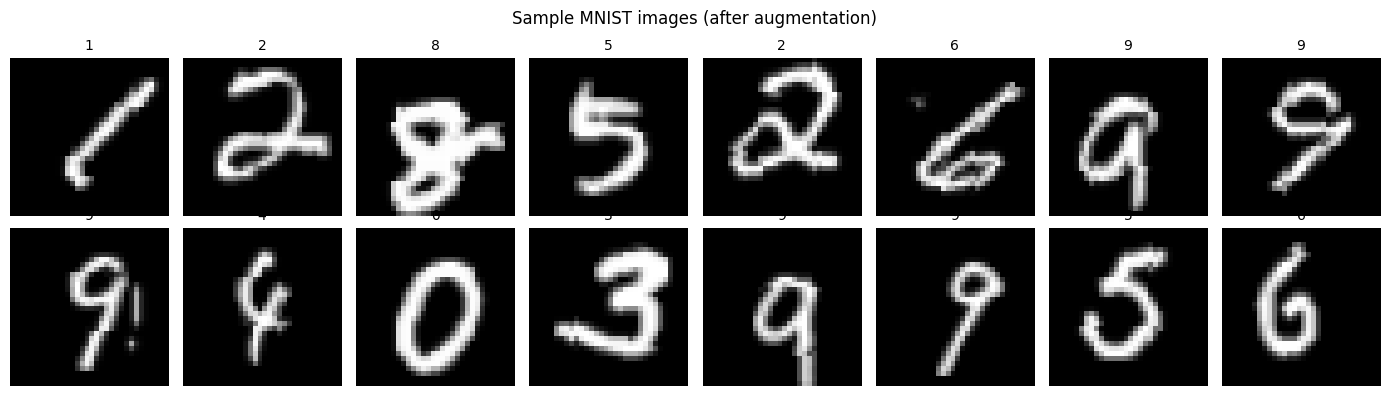

In [ ]:
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i].squeeze(), cmap='gray')
    ax.set_title(str(labels[i].item()), fontsize=10)
    ax.axis('off')
plt.suptitle('Sample MNIST images (after augmentation)', fontsize=12)
plt.tight_layout()
plt.show()

## 5 · Model: ResNet-18 adapted for MNIST

In [ ]:
def build_model(num_classes: int = 10) -> nn.Module:
    """
    ResNet-18 pre-trained on ImageNet, adapted for MNIST:
      • conv1  : 3-channel → 1-channel (grayscale)
      • fc     : 512 → num_classes
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    # Replace first conv: ImageNet expects 3-channel RGB, MNIST is 1-channel
    model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)

    # Replace final fully-connected layer
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    return model


model = build_model(NUM_CLASSES).to(device)

# Quick parameter count
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters    : {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 48.1MB/s]


Total parameters    : 11,175,370
Trainable parameters: 11,175,370


## 6 · Loss, optimiser & scheduler

In [ ]:
criterion = nn.CrossEntropyLoss()

# Adam with a moderate LR; fine-tuning pre-trained weights so we don't need
# to differentiate pre-trained vs new layers for this short run.
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Cosine annealing: smoothly decays LR to near 0 over all epochs
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

## 7 · Training & evaluation loop

In [ ]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0

    for batch_idx, (images, labels) in enumerate(loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

        if (batch_idx + 1) % 200 == 0:
            print(f'  Batch [{batch_idx+1}/{len(loader)}]  '
                  f'Loss: {running_loss/total:.4f}  '
                  f'Acc: {100.*correct/total:.2f}%')

    return running_loss / total, 100. * correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss    = criterion(outputs, labels)

        running_loss += loss.item() * images.size(0)
        _, predicted  = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total   += labels.size(0)

    return running_loss / total, 100. * correct / total

In [ ]:
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print('=' * 60)
print(f'Fine-tuning ResNet-18 on MNIST for {NUM_EPOCHS} epoch(s)')
print('=' * 60)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f'\nEpoch {epoch}/{NUM_EPOCHS}  (lr={scheduler.get_last_lr()[0]:.2e})')
    print('-' * 40)

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss,   val_acc   = evaluate(model, test_loader, criterion, device)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f'  Train  — loss: {train_loss:.4f}  acc: {train_acc:.2f}%')
    print(f'  Test   — loss: {val_loss:.4f}  acc: {val_acc:.2f}%')

print('\n✅ Training complete!')

Fine-tuning ResNet-18 on MNIST for 3 epoch(s)

Epoch 1/3  (lr=1.00e-03)
----------------------------------------
  Batch [200/938]  Loss: 0.4853  Acc: 85.33%
  Batch [400/938]  Loss: 0.3427  Acc: 89.85%
  Batch [600/938]  Loss: 0.2822  Acc: 91.80%
  Batch [800/938]  Loss: 0.2426  Acc: 92.94%
  Train  — loss: 0.2235  acc: 93.52%
  Test   — loss: 0.0575  acc: 98.35%

Epoch 2/3  (lr=7.50e-04)
----------------------------------------
  Batch [200/938]  Loss: 0.0848  Acc: 97.48%
  Batch [400/938]  Loss: 0.0823  Acc: 97.57%
  Batch [600/938]  Loss: 0.0816  Acc: 97.64%
  Batch [800/938]  Loss: 0.0776  Acc: 97.77%
  Train  — loss: 0.0778  acc: 97.77%
  Test   — loss: 0.0635  acc: 97.92%

Epoch 3/3  (lr=2.50e-04)
----------------------------------------
  Batch [200/938]  Loss: 0.0480  Acc: 98.58%
  Batch [400/938]  Loss: 0.0463  Acc: 98.66%
  Batch [600/938]  Loss: 0.0439  Acc: 98.72%
  Batch [800/938]  Loss: 0.0416  Acc: 98.79%
  Train  — loss: 0.0413  acc: 98.78%
  Test   — loss: 0.0239  acc

## 8 · Training curves

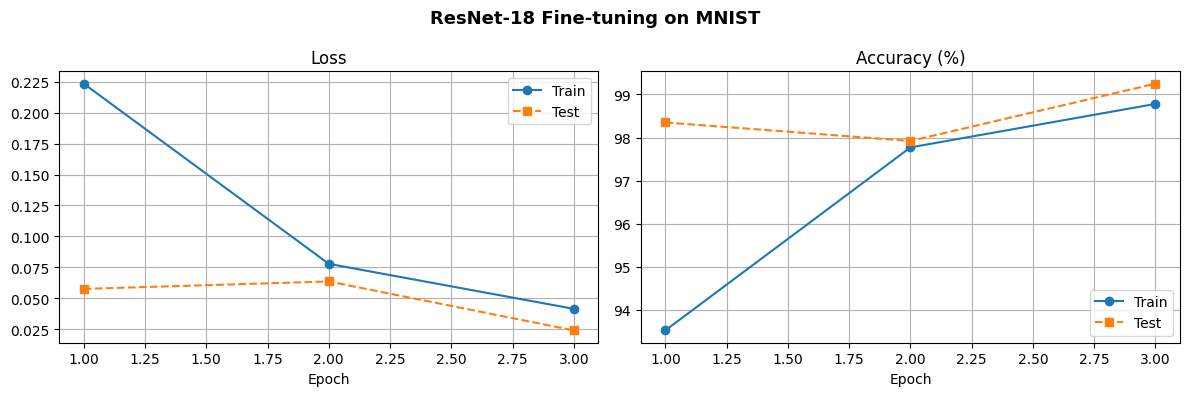

Saved training_curves.png


In [ ]:
epochs_range = range(1, NUM_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, history['train_loss'], 'o-', label='Train')
ax1.plot(epochs_range, history['val_loss'],   's--', label='Test')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend(); ax1.grid(True)

ax2.plot(epochs_range, history['train_acc'], 'o-', label='Train')
ax2.plot(epochs_range, history['val_acc'],   's--', label='Test')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend(); ax2.grid(True)

plt.suptitle('ResNet-18 Fine-tuning on MNIST', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved training_curves.png')

## 9 · Confusion matrix

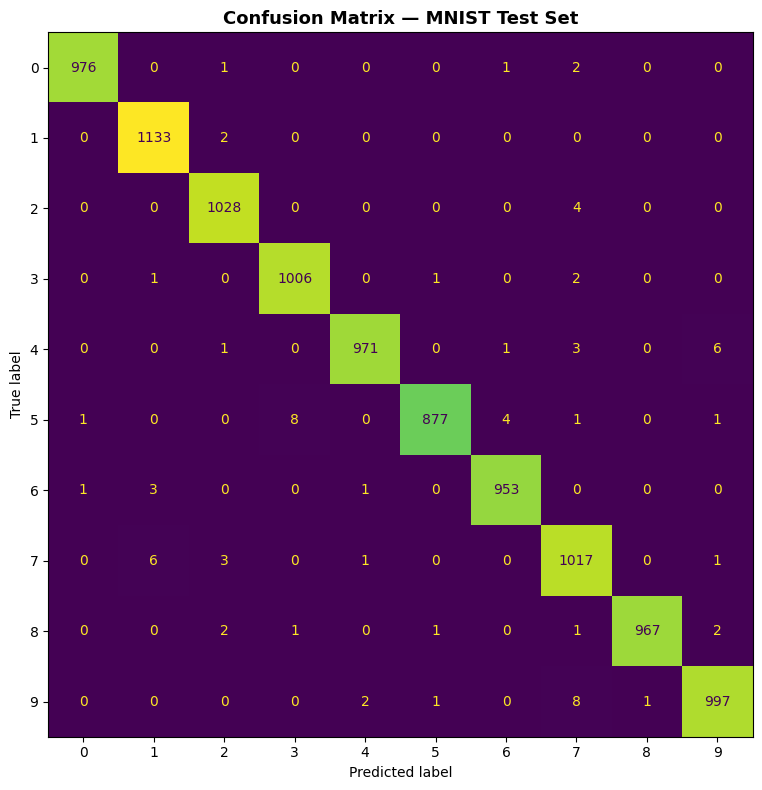

Test accuracy: 99.25%


In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds   = outputs.argmax(dim=1).cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(cm, display_labels=list(range(10))).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — MNIST Test Set', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Test accuracy: {100.*np.sum(np.array(all_preds)==np.array(all_labels))/len(all_labels):.2f}%')

## 10 · Save the model weights

We save **only the `state_dict`** (not the whole model object)

In [ ]:
torch.save(model.state_dict(), MODEL_PATH)
size_mb = os.path.getsize(MODEL_PATH) / 1e6
print(f'✅ Weights saved to "{MODEL_PATH}"  ({size_mb:.1f} MB)')
print('Download this file and upload it to your Hugging Face Space.')

✅ Weights saved to "mnist_cnn.pth"  (44.8 MB)
Download this file and upload it to your Hugging Face Space.


## 11 ·  Download from Colab

Run the cell below to download `mnist_cnn.pth` directly to your computer from Colab.

In [ ]:
try:
    from google.colab import files
    files.download(MODEL_PATH)
    print('Download triggered!')
except ImportError:
    print('Not running in Colab — find the file in your working directory.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Download triggered!
